# Tutorial 1: Sampling

**Week 2, Day 3: Time Series**

**By Neuromatch Academy (community contribution)**

**Content Creators:** 

**Content Reviewers:** Andreas Neef, Richard Gao

**Production editors:** *to be filled in*

---

# Tutorial Objectives

*Estimated timing of tutorial: *

In this tutorial, we build the foundation for working with digitised signals. Virtually any signal you will ever work with, will be presented to you in digital form. This happens through sampling.

**Sampling** is the discretisation of a continuous signal by measuring or recording the signal only at fixed moments in time and discarding everything in
between.

When we work with the sampled signal, we somehow interpret it also for the time points between the sample points. 

**Signal Reconstruction** turns a finite sequence of samples into a continuous signal estimate. 


Overview of the Tutorial section:

- Introduction of our workhorse for today: the sine wave
- Sample a continuous signal at different rates 
- Implement and compare strategies to visualize and reconstruct: lollipop plot, linear interpolation, and sinc convolution
- Understand the Nyquist–Shannon theorem from first principles and verify it numerically # TODO
- Identify aliasing and predict the apparent frequency of an undersampled signal
---

In [10]:
# ── INSTRUCTOR CONFIG ─────────────────────────────────────────
A_TRUE   = 1.5    # true amplitude
F_TRUE   = 5.0    # Hz — true frequency
PHI_TRUE = 1.0    # radians — true phase offset
DURATION = 1.0    # seconds
FS       = 1000   # samples per second
# ─────────────────────────────────────────────────────────────

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown

%matplotlib inline

t = np.linspace(0, DURATION, int(FS * DURATION), endpoint=False)
y_true = A_TRUE * np.sin(2 * np.pi * F_TRUE * t + PHI_TRUE)

## Part 1 — The Sine Wave

We will use sine waves as building blocks to represent any signal.
A sine wave is described by three parameters:

| Parameter | Symbol | What it controls |
|-----------|--------|------------------|
| **Amplitude** | $A$ | Height of the wave (how loud / how strong) |
| **Frequency** | $f$ | How many cycles per second (measured in Hz) |
| **Phase** | $\varphi$ | Where in its cycle the wave starts (in radians) |

Together they give:

$$s(t) = A \cdot \sin(2\pi f t + \varphi)$$

## Coding Exercise 1.1 — Implement the sine wave

Before you play with the sliders, write the sine-wave equation yourself.

Fill in `make_sine_wave(t, A, f, phi)` below so that it returns

$$s(t) = A \cdot \sin(2\pi f t + \varphi)$$

evaluated at every time sample in `t`. The widget further down the page calls
this function. The goal of the widget is to find the correct parameters to redraw a **mystery signal** (gray dashed line).
Watch how each slider changes the shape of your signal (blue), and try
to drive the **MSE as close to 0 as possible** to draw your reconstruction (blue)

Once you implement the sine function correctly, the sliders will spring to life.

In [55]:
def make_sine_wave(t, A, f, phi):
    """Generate a sine wave.

    Args:
        t (ndarray): time samples in seconds, shape (n_samples,)
        A (float):   amplitude
        f (float):   frequency in Hz
        phi (float): phase offset in radians

    Returns:
        ndarray: s(t) = A * sin(2π f t + φ), shape (n_samples,)
    """
    ####################################################
    ## TODO for students: implement the sine-wave equation
    # Fill out function and remove the NotImplementedError below
    # raise NotImplementedError("Student exercise: implement the sine wave equation")
    ####################################################

    # Compute the sine wave  s(t) = A · sin(2π f t + φ)
    s = A*np.sin(2*np.pi*f*t + phi)

    return s


<details>
<summary><b>📖 Click to reveal solution</b></summary>

<pre><code>def make_sine_wave(t, A, f, phi):
    s = A * np.sin(2 * np.pi * f * t + phi)
    return s
</code></pre>

</details>


### Interactive Demo 1: Properties of a sine wave


In [56]:
import io

amp_slider = widgets.FloatSlider(
    value=1.0, min=0.0, max=3.0, step=0.05,
    description='Amplitude (A)',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='420px')
)

freq_slider = widgets.FloatSlider(
    value=1.0, min=1.0, max=20.0, step=0.5,
    description='Frequency f (Hz)',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='420px')
)

phase_slider = widgets.FloatSlider(
    value=0.0, min=0.0, max=2 * np.pi, step=0.05,
    description='Phase φ (rad)',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='420px'),
    readout_format='.2f'
)

img_out = widgets.Image(format='png')


def update(_change=None):
    A   = amp_slider.value
    f   = freq_slider.value
    phi = phase_slider.value

    y_student = make_sine_wave(t, A, f, phi)
    mse = np.mean((y_true - y_student) ** 2)

    fig, ax = plt.subplots(figsize=(9, 4))

    ax.plot(t, y_true, color='#888888', linestyle='--', linewidth=2,
            label='Target signal', alpha=0.85)
    ax.plot(t, y_student, color='#2563EB', linewidth=2,
            label=f'Your signal  (A={A:.2f}, f={f:.1f} Hz, φ={phi:.2f} rad)')

    ax.set_title('Single Sine Wave — Match the Target', fontsize=14)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim(0, DURATION)
    ax.set_ylim(-3.5, 3.5)

    mse_color = '#16a34a' if mse < 0.01 else '#dc2626'
    ax.text(
        0.02, 0.95, f'MSE: {mse:.4f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        color=mse_color,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=mse_color, alpha=0.8)
    )

    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img_out.value = buf.read()


controls = widgets.VBox(
    [amp_slider, freq_slider, phase_slider],
    layout=widgets.Layout(width='450px')
)

img_out = widgets.Image(
    format='png',
    layout=widgets.Layout(
        width='100%',
        min_height='500px'
    )
)

ui = widgets.VBox(
    [controls, img_out],
    layout=widgets.Layout(width='100%', align_items='flex-start')
)

amp_slider.observe(update, names='value')
freq_slider.observe(update, names='value')
phase_slider.observe(update, names='value')

display(ui)
update()


## Anatomy of a Sine Wave

$$\boxed{s(t) = A \cdot \sin(2\pi f t + \varphi)}$$

### Amplitude $A$
Controls the **peak value** of the wave. Doubling $A$ doubles the height without
changing the speed or timing of the oscillation. In physical systems, amplitude
often relates to energy: signal power scales as $A^2$.

### Frequency $f$
Controls how many **full cycles** occur per second (unit: Hz = cycles/second).
A higher frequency means a faster oscillation and a shorter period:

$$T = \frac{1}{f}$$

The factor $2\pi$ converts from cycles/second to **angular frequency**
$\omega = 2\pi f$ (radians/second), because one full cycle spans $2\pi$ radians.

### Phase $\varphi$
Controls the **starting position** of the oscillation at $t = 0$ (unit: radians).
A phase of $\varphi = \pi/2$ shifts the sine into a cosine;
$\varphi = \pi$ flips it upside down.
Phase only matters *relative* to another signal — a single isolated sine wave with
any phase looks the same in the frequency domain.

### Key intuitions
- Moving the **amplitude slider** stretches the wave **vertically**.
- Moving the **frequency slider** compresses the wave **horizontally** (more wiggles per second).
- Moving the **phase slider** **slides** the wave left or right in time.

# Setup

## Install and import feedback gadget


In [57]:
# @title Install and import feedback gadget
!pip3 install vibecheck datatops --quiet
from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "neuromatch_cn",
            "user_key": "y1x3mpx5",
        },
    ).render()
feedback_prefix = "W2D2_T3S1"

In [58]:
# @title Imports
import numpy as np
from numpy.fft import rfft, rfftfreq
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from ipywidgets import interact
import warnings
warnings.filterwarnings('ignore')

## Figure settings

In [59]:
# @title Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

In [60]:
# @title Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
import matplotlib.gridspec as gridspec
import ipywidgets as widgets
from IPython.display import display, HTML

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")
plt.rcParams.update({'figure.facecolor' : 'white',
                     'axes.facecolor'   : 'white',
                     'savefig.facecolor': 'white'})
display(HTML("""
<style>
  .widget-output { background: white !important;
                   border: none !important; padding: 0 !important; }
</style>"""))

# Helper functions

---

# Part 2: Sampling

*Estimated timing to here from start of tutorial: min*


## Video 1: Subsampling


In [61]:
from IPython.display import HTML
HTML("<div style='background:#eee;padding:1em;border-radius:6px;'>"
     "<b>Video 1 placeholder.</b> Topics: Subsampling intro from true signals; sampling frequency"
     "</div>")

In [62]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Video_1_Subsampling")


## What is Sampling?

Processes in the real world unfold in continuous time and in continuous-valued, analog variables $x(t)$. Think, for instance, of the value of a voltage at an EEG electrode: it has a magnitude, expressed as a real number with a unit, at *any* time $t$. Nowadays, virtually every device captures, stores, and handles variables in a *digitized* form. 
**Sampling** turns the continuous-time signal $x(t)$ into a sequence of numbers $x[t_n]$ by measuring the signal at regular time intervals.

Sampling always throws away some information, but under certain conditions, you can still reconstruct the original continuous signal perfectly. 

A few definitions:

$\Delta t$ - sample interval

$f_s=1/\Delta t$ - sample frequency


Mathematically, if the original signal is $x(t)$ and the sampling interval
is $T = 1/f_s$, then what your device records is:

$$x_i = x[t_i] = x(t_0 + i\cdot\Delta t), \qquad i = 0, 1, 2, \ldots$$

Practically, sampling is always accompanied by amplitude discretization because $x_i$ is internally represented as an integer number of bits and thus the values live in some finite interval that is tiled by a finite number of discrete values (8 bits = 256 values; 10 bits = 4096 values). You might be familiar with this from digital images. For now, we ignore the amplitude discretization and assume that the number of bits is so high that we capture the signal amplitude without error. 

Similarly, when we present the "original" signal in any of the widgets, we actually present a very finely sampled digital version. When you then sample with a coarser grid from the already sampled data, we could speak of **subsampling**, but we keep it simple and write "sampling". 


## Coding Exercise 1.2: Implement sampling


Complete the function below. Given the full dense signal and a target
sampling rate, return the times and values of the sampled points.

**Hint:** compute the step size as multiples of the much smaller original step size `round(FS_TRUE / fs)` and use
`np.arange` to pick every $k$-th index.

In [63]:
# @title True Signal Generation — run this cell

FS_TRUE   = 10_000.0   # dense axis, treated as continuous
F_SIGNAL  = 5.0        # Hz — sine wave frequency
DURATION  = 1.0        # seconds — displayed window
TOTAL_DUR = 100.0      # seconds — full context for sinc reconstruction

# ── sine signal ──────────────────────────────────────────────
_N          = int(FS_TRUE * TOTAL_DUR)
_t_total    = np.linspace(0, TOTAL_DUR, _N, endpoint=False)
_sig_sine   = np.sin(2 * np.pi * F_SIGNAL * _t_total)

_start_t    = (TOTAL_DUR - DURATION) / 2
_mask       = (_t_total >= _start_t) & (_t_total < _start_t + DURATION)
t_eval      = _t_total[_mask]          # total-time axis — used in sinc, never shifted
t_plot      = t_eval - _start_t        # 0–1 s axis — used only for plotting
sig_true    = _sig_sine[_mask]         # ground truth: same array as _sig_sine

# ── transient evoked signal ───────────────────────────────────
F_TRANSIENT  = 60.0    # Hz — carrier frequency of the transient
_center      = TOTAL_DUR / 2
_sigma       = 0.05  
_envelope    = np.exp(-((_t_total - _center)**2) / (2 * _sigma**2))
_sig_trans   = _envelope * np.sin(2 * np.pi * F_TRANSIENT * _t_total)

sig_transient = _sig_trans[_mask]

print(f'Sine signal:      {len(sig_true)} samples in display window')
print(f'Transient signal: peak = {sig_transient.max():.3f}, '
      f'carrier = {F_TRANSIENT} Hz')

Sine signal:      10000 samples in display window
Transient signal: peak = 0.996, carrier = 60.0 Hz


In [64]:
# @markdown Execute after completing the function

def subsample(t_total, sig_total, fs, phase):
    """Subsample a dense signal at a target rate.

    Parameters
    ----------
    t_total   : (N,) full time axis at FS_TRUE resolution
    sig_total : (N,) full signal
    fs        : float, target sampling rate in Hz

    Returns
    -------
    t_samp : (M,) sample times
    y_samp : (M,) sample values
    """
    ##############################################################################
    # TODO: compute step size and return every step-th sample
    step   = max(1, int(round(FS_TRUE / fs))) # make it max(1, int(round(...)))
    idx    = np.arange(int(np.round(0+phase/2/np.pi*step)), len(t_total), step) # make it np.arange(0, len(t_total), ...)
    return t_total[idx], sig_total[idx]
    ##############################################################################


# --- test ---
t_samp, y_samp = subsample(_t_total, _sig_sine, fs=20,phase=0)
print(f'fs=20 Hz → {len(t_samp)} total samples, '
      f'step = {round(FS_TRUE/20)} samples')
assert len(t_samp) == 2000, 'Expected 2000 samples for fs=20 over 100 s'
print('Test passed ✓')
print('')

fs=20 Hz → 2000 total samples, step = 500 samples
Test passed ✓



[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D3_LinearSystems/solutions/W2D3_Tutorial1_Solution_lti.py)


### We have 100 s of data sampled at 20 Hz from an underlying simulated ground truth signal with 10000 Hz

In [65]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Exercise_1_LTI")


---

# Part 3: Reconstruction

*Estimated timing to here from start of tutorial: min*


In [68]:
# @title Video 2: Convolution as flip-and-slide
from IPython.display import HTML
HTML('<div style="background:#eee;padding:1em;border-radius:6px;">'
     '<b>Video 2 placeholder.</b> Topics: Reconstruction strategies: straight lines, lollipop and sinc'
     '</div>')

In [69]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Video_2_Convolution")

## Reconstruction strategies

Once we have discrete samples $x[i]$, you need to estimate the
signal at times between samples. There are three strategies:


**Lollipop** : plot only the sample values as vertical stems. This shows exactly what was measured. Information between the samples is not considered.


**Linear interpolation** : connect adjacent samples with straight lines:

Use `np.interp(t_eval, t_samp, y_samp)`.

**Sinc interpolation** : we will look at this later after understanding the limitations of the other two.

## Coding Exercise 2: Implement linear interpolation

In [70]:

def get_one_second_signal_to_visualize(t_samp, y_samp, start_t):
    """Return sample positions shifted to the 0–1 s plot axis.

    Parameters
    ----------
    t_samp  : (M,) sample times on the total-time axis
    y_samp  : (M,) sample values
    start_t : float, offset of the display window

    Returns
    -------
    t_vis : visible sample times shifted to 0–1 s
    y_vis : corresponding sample values
    """
    ##############################################################################
    in_win = (t_samp >= start_t) & (t_samp < start_t + DURATION)
    t_vis  = t_samp[in_win] - start_t
    y_vis  = y_samp[in_win]
    return t_vis, y_vis
    ##############################################################################


### Interactive Demo 2: Different visualizations of sampled data

In [71]:
# @title Helper: plot_reconstruction — run this cell

def plot_reconstruction(fs, mode):
    t_samp, y_samp = subsample(_t_total, _sig_sine, fs,phase=0)
    t_v, y_v       = get_one_second_signal_to_visualize(t_samp, y_samp, _start_t)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6),
                             constrained_layout=True, sharex=True)
    fig.set_facecolor('white')

    # top: true + samples
    ax = axes[0]
    ax.plot(t_plot, sig_true, color='#3778bf', lw=1.8,
            alpha=0.85, label='True signal', zorder=2)
    ax.plot(t_v, y_v, 'o', color='#d62728', markersize=5.5,
            zorder=4, label=f'Samples ({len(t_v)} in window)')
    ax.set(ylabel='Amplitude', ylim=(-1.25, 1.25),
           title=f'True signal and samples  (fs = {fs} Hz)')
    ax.legend(fontsize=9, framealpha=0.9, loc='upper right')
    ax.grid(True, alpha=0.20)

    # bottom: reconstruction
    ax = axes[1]
    ax.plot(t_plot, sig_true, color='#3778bf', lw=1.4,
            alpha=0.25, label='True signal (reference)', zorder=1)
    ##############################################################################
    #TODO: fill in the lines to plot the reconstruction according to the selected mode
    ##############################################################################
    
    if mode == 'lollipop':
        ax.plot(t_v, y_v, 'o', color='#d62728', markersize=5.5,
                label='Lollipop', zorder=4)
        ax.vlines(t_v, 0, y_v, color='#d62728', lw=1.3, alpha=0.75, zorder=3) ##  make it  ax.vlines(t_v, ..., ..., color='#d62728', lw=1.3, alpha=0.75, zorder=3)
        
        title = 'Lollipop'

    elif mode == 'linear':
   
        ax.plot(t_v, y_v, '-o', color='#d62728', markersize=4, zorder=4) ## make it ax.plot(t_v, ... , ... , color='#d62728', markersize=4, zorder=4)
        title = 'Linear - straight lines between samples'

    else:
        print(f'Unknown mode: {mode}')

    ax.set(xlabel='Time (s)', ylabel='Amplitude',
           ylim=(-1.25, 1.25), title=title)
    ax.legend(fontsize=9, framealpha=0.9, loc='upper right')
    ax.grid(True, alpha=0.20)
    plt.show()
    
# @markdown Execute to compare reconstruction strategies

@widgets.interact(
   
    mode = widgets.RadioButtons(
               options=[('Lollipop',                'lollipop'),
                        ('Straight-line connectors', 'linear'),
                        #('Sinc reconstruction',      'sinc')
                        ],
               value='lollipop',
               description='Method:',
               style={'description_width': '70px'})
)
def visualize_reconstruction( mode='lollipop'):
    plot_reconstruction(fs=15, mode = mode)

interactive(children=(RadioButtons(description='Method:', options=(('Lollipop', 'lollipop'), ('Straight-line c…

## Think! 1: Are these optimal reconstruction strategies?

You have now seen two ways to represent the sampled signal.

----
- The lollipop indicates the value at each sample instant and avoids claims about the signal in between them. It is thus the most conservative representation. It does not mislead you to make unfounded assumptions about the signal in the intervals between samples.

- The straight-line connector fills in the gaps, but assumes the signal
  changes at a constant rate between any two adjacent samples. If the signal had been sampled so densely that even the fastest excursions were well represented, this could be an acceptable representation. 
----
\
Look at the sampled sine wave. At 3 sample points per period, the linear interpolation does a bad job at approximating the original signal; for instance, it grossly underestimates the peak-to-peak amplitude.

**Question 1** : Make a guess at how many samples per period you would find the linear interpolation acceptable. Would four suffice?

**Question 2** : Make a guess as to how many samples per period are *minimally required* to reconstruct the sine wave perfectly. 

**Question 3** : If you only knew the sampled points, but nothing about the nature of the original signal, how many different plausible signals could you draw through those samples?


### The sinc function

As you will see soon, it is possible to sample a signal without losing any information, provided that the sample frequency is sufficiently high. You will soon experiment to see what "sufficient" could encompass.
If the original signal has been sampled in this way, it can be reconstructed from the samples by convolution with the sinc function:

$$\operatorname{sinc}(u) = \frac{\sin(\pi u)}{\pi u}$$

It is a sine wave divided by its argument. It oscillates like a sine wave. At $u = 0$ the amplitude is 1, which is the global maximum.
As $|u|$ grows, the oscillations wane, and the amplitude approaches zero. The form we use here, with the factor $\pi$ in the argument, is the *normalized* sinc function. It hits zero at every nonzero integer at $u = \pm 1, \pm 2, \pm 3,
\ldots$ .

## Coding Exercise 3: Sinc function


Before using sinc reconstruction, implement the sinc function yourself
from its definition:

$$\operatorname{sinc}(u) = \frac{\sin(\pi u)}{\pi u}$$

At $u = 0$ the expression $0/0$ is indeterminate. Handle this as a
special case, the limit is 1, so set $\operatorname{sinc}(0) = 1$.

**Hint:** use `np.sin`, `np.pi`, and `np.where` to handle the
$u = 0$ case without dividing by zero.

All tests passed ✓


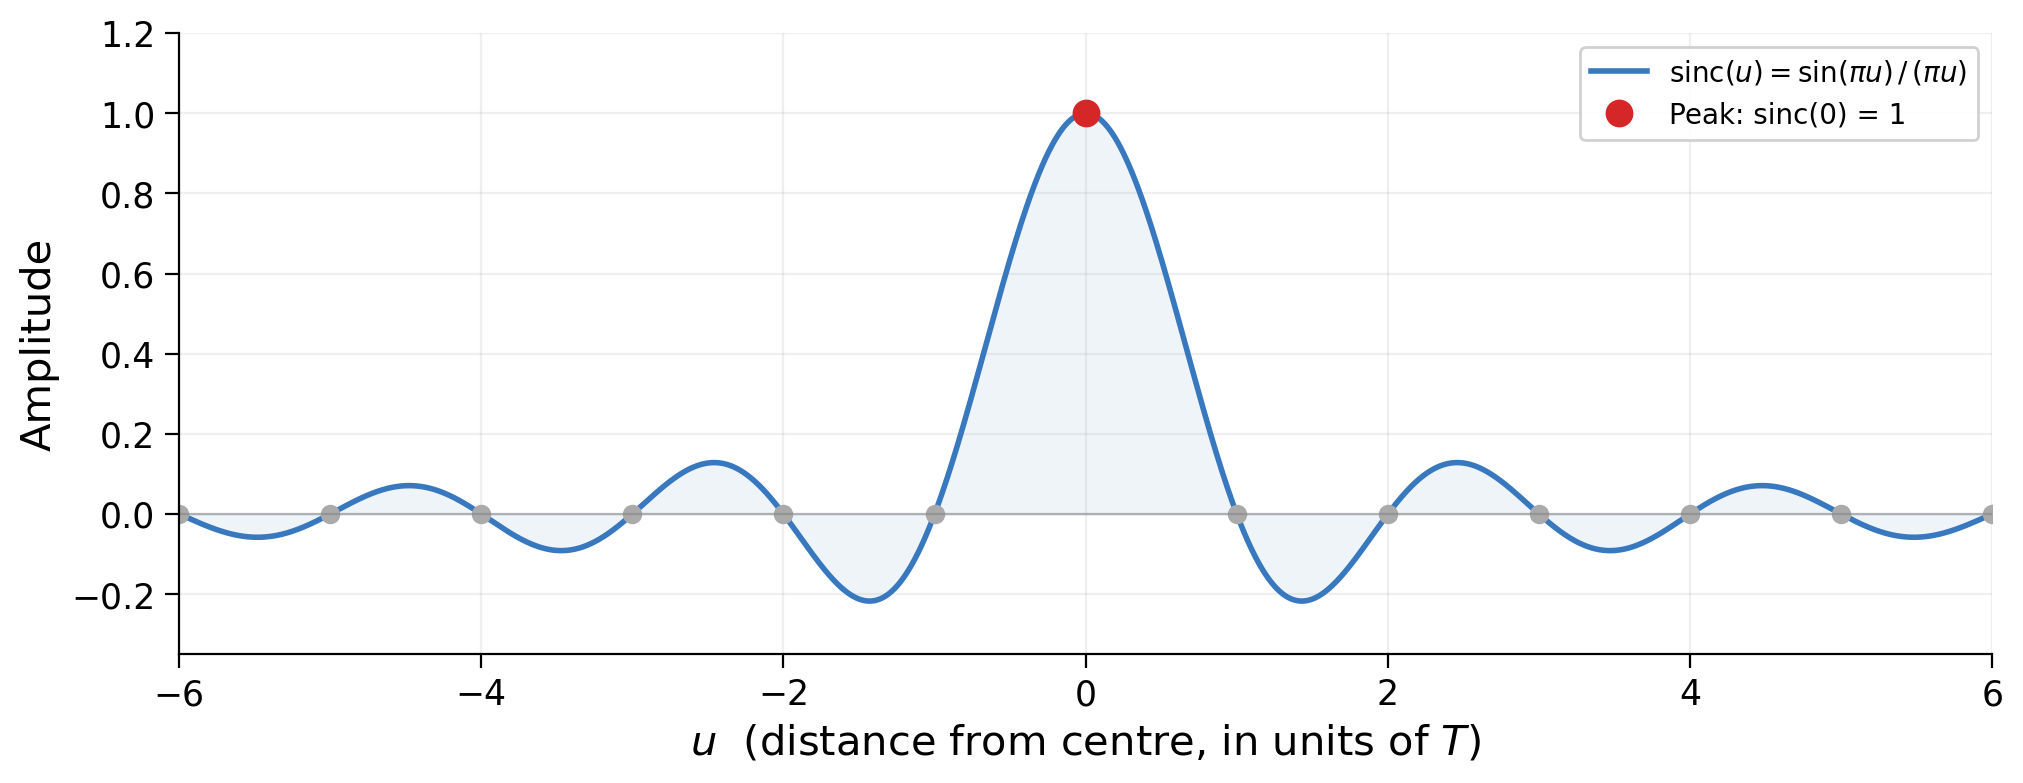

In [72]:
# @markdown Execute after completing the function

def sinc(u):
    """Evaluate the sinc function at u.

    Parameters
    ----------
    u : float or np.ndarray
        Argument(s) to evaluate. Units are normalised sample intervals.

    Returns
    -------
    float or np.ndarray
        sinc(u) = sin(pi * u) / (pi * u), with sinc(0) = 1.
    """
    u = np.asarray(u, dtype=float)

    ##############################################################################
    # TODO: compute sin(pi * u) / (pi * u) and handle the u=0 case
    # Hint: np.where(condition, value_if_true, value_if_false)
    denom = np.pi * u
    y     = np.where(u == 0, 1.0, np.sin(denom) / denom) ## make it np.where(u == ..., 1.0, np.sin(...) / ...)
    return y
    ##############################################################################


# ── test ─────────────────────────────────────────────────────
assert np.isclose(sinc(0),    1.0),  'sinc(0) should be 1'
assert np.isclose(sinc(1),    0.0),  'sinc(1) should be 0'
assert np.isclose(sinc(-1),   0.0),  'sinc(-1) should be 0'
assert np.isclose(sinc(0.5),  2/np.pi), 'sinc(0.5) should be 2/pi'
print('All tests passed ✓')

# ── visualise ─────────────────────────────────────────────────
u        = np.linspace(-6, 6, 10_000)
y        = sinc(u)
integers = np.arange(-6, 7)

fig, ax = plt.subplots(figsize=(10, 3.8), constrained_layout=True)
fig.set_facecolor('white')

ax.plot(u, y, color='#3778bf', lw=2.0, zorder=2,
        label=r'$\mathrm{sinc}(u) = \sin(\pi u)\,/\,(\pi u)$')
ax.fill_between(u, y, alpha=0.08, color='#3778bf')

# zero crossings at nonzero integers
ax.stem(integers[integers != 0],
        sinc(integers[integers != 0]),
        linefmt='#aaaaaa', markerfmt='o', basefmt='none')

# peak
ax.plot(0, 1, 'o', color='#d62728', markersize=9,
        zorder=5, label='Peak: sinc(0) = 1')

ax.axhline(0, color='gray', lw=0.8, alpha=0.5)
ax.set(xlabel='$u$  (distance from centre, in units of $T$)',
       ylabel='Amplitude',
       xlim=(-6, 6), ylim=(-0.35, 1.2))
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.20)
plt.show()

## Interpolating using sinc function

To reconstruct the signal at any time point $t$, center one sinc function at each sample point and multiply it with the sampled signal amplitude at this point $x[n]$. Finally, sum over all the scaled sinc contributions:

$$\hat{x}(t) = \sum_{n} x[n] \cdot \operatorname{sinc}\!\left(\frac{t - nT}{T}\right)$$

The argument $\frac{t - nT}{T}$ measures how far the evaluation point
$t$ is from sample $n$, in units of the sampling interval $T$. Each sinc peaks at its own sample and is zero at all others. So you can see straight away, that the reconstructed, continuous signal runs indeed through all sample points.

In [73]:

def reconstruct_sinc(t_samp, y_samp,t_eval):
    """
    Whittaker–Shannon sinc reconstruction.

    Uses the nearest n_terms samples on each side of every evaluation
    point — sinc tails beyond that are below one display pixel.

    Parameters
    ----------
    t_samp  : (M,) sample times (total-time axis, full 100 s context)
    y_samp  : (M,) sample values
    t_eval  : (N,) evaluation times (total-time axis)
    n_terms : int, half-width of the local sinc window

    Returns
    -------
    y_hat : (N,) reconstructed signal
    """
    ##############################################################
   
    T = t_samp[1] - t_samp[0]
    # generate a denser grid than the samples, to get the intermediate values
    y_hat = np.zeros(len(t_eval))
    for i, t in enumerate(t_eval):
        diff = (t - t_samp) / T ## make it (t - ...) / ...
        y_hat[i] = (y_samp * sinc(diff)).sum()  ## make it (y_samp * sinc(...)).sum()
    return t_eval, y_hat
    #############################################################


# --- test ---
t_samp, y_samp = subsample(_t_total, _sig_sine, fs=20,phase = 0)
t_eval, y_sinc  = reconstruct_sinc(t_samp, y_samp,t_eval )

#assert y_sinc.shape == sig_true.shape, 'Sinc output shape mismatch'
print('All reconstruction tests passed ✓')

All reconstruction tests passed ✓


### Interactive Demo 3: Comparing reconstruction strategies

Use the interactive demo below to compare the three strategies at a
**fixed** sampling rate and signal. The true signal is a $5$ Hz sine
wave sampled from a $100$-second context window.


In [74]:
# @title Helper: plot_reconstruction — run this cell

def plot_reconstruction(fs, mode , t_eval,phase):
    t_samp, y_samp = subsample(_t_total, _sig_sine, fs,phase)
    t_v, y_v       = get_one_second_signal_to_visualize(t_samp, y_samp, _start_t)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6),
                             constrained_layout=True, sharex=True)
    fig.set_facecolor('white')

    # top: true + samples
    ax = axes[0]
    ax.plot(t_plot, sig_true, color='#3778bf', lw=1.8,
            alpha=0.85, label='True signal', zorder=2)
    ax.plot(t_v, y_v, 'o', color='#d62728', markersize=5.5,
            zorder=4, label=f'Samples ({len(t_v)} in window)')
    ax.set(ylabel='Amplitude', ylim=(-1.25, 1.25),
           title=f'True signal and samples  (fs = {fs} Hz)')
    ax.legend(fontsize=9, framealpha=0.9, loc='upper right')
    ax.grid(True, alpha=0.20)

    # bottom: reconstruction
    ax = axes[1]
    ax.plot(t_plot, sig_true, color='#3778bf', lw=1.4,
            alpha=0.25, label='True signal (reference)', zorder=1)

    if mode == 'lollipop':
        ax.plot(t_v, y_v, 'o', color='#d62728', markersize=5.5,
                label='Lollipop', zorder=4)
        ax.vlines(t_v, 0, y_v, color='#d62728', lw=1.3, alpha=0.75, zorder=3) ##  make it  ax.vlines(t_v, ..., ..., color='#d62728', lw=1.3, alpha=0.75, zorder=3)
        
        title = 'Lollipop'

    elif mode == 'linear':
   
        ax.plot(t_v, y_v, '-o', color='#d62728', markersize=4, zorder=4) ## make it ax.plot(t_v, ... , ... , color='#d62728', markersize=4, zorder=4)
        title = 'Linear - straight lines between samples'


    else:
        t_eval, y_sinc = reconstruct_sinc(t_samp, y_samp,t_eval)
        t_v1, y_v1       = get_one_second_signal_to_visualize(t_eval, y_sinc, _start_t)
        ax.plot(t_v1,y_v1, color='#9467bd', lw=1.8,label='Sinc reconstruction', zorder=3)
        
        ax.plot(t_v, y_v, 'o', color='#d62728', markersize=4, zorder=4)
        title = 'Sinc — Whittaker–Shannon reconstruction'

    ax.set(xlabel='Time (s)', ylabel='Amplitude',
           ylim=(-1.25, 1.25), title=title)
    ax.legend(fontsize=9, framealpha=0.9, loc='upper right')
    ax.grid(True, alpha=0.20)
    plt.show()

# @markdown Execute to compare reconstruction strategies

@widgets.interact(
    #fs   = widgets.IntSlider(value=15, min=11, max=80, step=1,
    #                         description='fs (Hz):',
    #                         style={'description_width': '70px'},
    #                         layout=widgets.Layout(width='480px')),
    mode = widgets.RadioButtons(
               options=[('Lollipop',                'lollipop'),
                        ('Straight-line connectors', 'linear'),
                        ('Sinc reconstruction',      'sinc')
                        ],
               value='lollipop',
               description='Method:',
               style={'description_width': '70px'})
)
def visualize_reconstruction(mode='lollipop'):
    plot_reconstruction(fs = 15, mode = mode , t_eval = t_eval,phase=0)

interactive(children=(RadioButtons(description='Method:', options=(('Lollipop', 'lollipop'), ('Straight-line c…

## Think! 2: Why is the sinc recosntruction so good?

---

# Part 4: Effect of sampling rate

*Estimated timing to here from start of tutorial: min*



You have confirmed that sinc reconstruction was able to reconstruct the sine waves from 3 sample points per period. Next study **how low can the sampling rate drop before sinc reconstruction fails?**


## Interactive Demo 4: Find the frequency at which reconstruction fails


The demo below fixes sinc as the reconstruction method and lets you
vary $f_s$. There are two signals to explore:

1. **Sine wave** : a pure $5$ Hz oscillation. Watch the sinc
   reconstruction degrade as you approach then cross a critical threshold.

2. **Transient response** : a brief oscillatory burst (like a
   stimulus-locked high-gamma response). The lower subplot shows its
   **power spectrum** 
**Your task:** for each signal, find the lowest $f_s$ at which sinc
reconstruction still accurately recovers the signal. Write those two
numbers down before reading the next Section.

In [53]:
# @markdown Execute after completing the function

def reconstruction_error(sig_true, sig_recon):
    """Compute RMSE between true and reconstructed signal.

    Parameters
    ----------
    sig_true  : (N,) ground truth signal
    sig_recon : (N,) reconstructed signal

    Returns
    -------
    float : root mean square error
    """
    ##############################################################################
    return np.sqrt(np.mean((sig_true - sig_recon) ** 2))
    ##############################################################################


In [54]:
# @title Helper: plot_sinc_explorer — run this cell

def plot_sinc_explorer(fs, signal_type , t_eval,phase):
    if signal_type == 'sine':
        sig_full  = _sig_sine
        sig_disp  = sig_true
        f_label   = f'{F_SIGNAL} Hz sine'
    else:
        sig_full  = _sig_trans
        sig_disp  = sig_transient

        f_label   = f'Transient signal with maximum power upto 72 Hz'

    t_samp, y_samp = subsample(_t_total, sig_full, fs,phase)
    t_eval, y_sinc = reconstruct_sinc(t_samp, y_samp, t_eval)
    t_v, y_v       =  get_one_second_signal_to_visualize(t_samp, y_samp, _start_t)
    rmse           = reconstruction_error(sig_disp, y_sinc)

    fig = plt.figure(figsize=(10, 7), constrained_layout=True)
    fig.set_facecolor('white')
    gs  = gridspec.GridSpec(3, 1, figure=fig, height_ratios=[2, 2, 1.2])

    # ── top: true + samples ───────────────────────────────────
    ax0 = fig.add_subplot(gs[0])
    ax0.plot(t_plot, sig_disp, color='#3778bf', lw=1.8,
             alpha=0.85, label='True signal', zorder=2)
    ax0.plot(t_v, y_v, 'o', color='#d62728', markersize=5,
             zorder=4, label=f'Samples ({len(t_v)})')
    ax0.set(ylabel='Amplitude', ylim=(-1.25, 1.25),
            title=f'{f_label}')
    ax0.legend(fontsize=9, loc='upper right', framealpha=0.9)
    ax0.grid(True, alpha=0.20)

    # ── middle: sinc reconstruction ──────────────────────────
    ax1 = fig.add_subplot(gs[1], sharex=ax0)
    ax1.plot(t_plot, sig_disp, color='#3778bf', lw=1.4,
             alpha=0.25, label='True signal (reference)', zorder=1)
    ax1.plot(t_plot, y_sinc, color='#9467bd', lw=1.8,
             label='Sinc reconstruction', zorder=3)
    ax1.plot(t_v, y_v, 'o', color='#d62728', markersize=4, zorder=4)
    ax1.text(0.99, 0.95, f'RMSE = {rmse:.4f}',
             transform=ax1.transAxes, fontsize=10,
             ha='right', va='top',
             color='#27ae60' if rmse < 0.05 else '#c0392b',
             fontweight='bold')
    ax1.set(ylabel='Amplitude', ylim=(-1.25, 1.25),
            title='Sinc reconstruction')
    ax1.legend(fontsize=9, loc='upper right', framealpha=0.9)
    ax1.grid(True, alpha=0.20)
    print(f'RMSE of sinc reconstruction: {rmse:.4f}')

    # ── bottom: power spectrum ───────────────────────────────
    #ax2 = fig.add_subplot(gs[2])
    #freqs = rfftfreq(len(sig_disp), 1.0 / FS_TRUE)
    #power = np.abs(rfft(sig_disp))**2
    #power_r = np.abs(rfft(y_sinc))**2
    #ax2.semilogy(freqs, power,   color='#3778bf', lw=1.4,
    #             alpha=0.6, label='True')
    #ax2.semilogy(freqs, power_r, color='#9467bd', lw=1.4,
    #             alpha=0.8, label='Reconstructed', ls='--')
    #ax2.axvline(fs / 2, color='#e74c3c', lw=1.3, ls='--',
    #            label=f'Nyquist = {fs/2:.0f} Hz')
    #ax2.set(xlabel='Frequency (Hz)', ylabel='Power',
    #        xlim=(0, min(FS_TRUE/2, 200)),
    #        title='Power spectrum')
    #if signal_type == 'sine':
    #        ax2.set_xlim((0,20))
    #else:
    #        ax2.set_xlim((0,300))
    #ax2.legend(fontsize=9, loc='upper right', framealpha=0.9)
    #ax2.grid(True, alpha=0.20)
    plt.show()
    
# @markdown Execute to explore the effect of sampling rate

@widgets.interact(
    fs = widgets.IntSlider(value=30, min=5, max=500, step=1,
                           description='fs (Hz):',
                           style={'description_width': '70px'},
                           layout=widgets.Layout(width='500px')),
    signal_type = widgets.RadioButtons(
                      options=[('Sine wave',          'sine'),
                               ('Transient response', 'transient')],
                      value='sine',
                      description='Signal:',
                      style={'description_width': '70px'})
)
def visualize_sinc_explorer(fs=30, signal_type='sine'):
    plot_sinc_explorer(fs, signal_type , t_eval,phase=0)

interactive(children=(IntSlider(value=30, description='fs (Hz):', layout=Layout(width='500px'), max=500, min=5…

## The Nyquist–Shannon sampling theorem


In [55]:
# @title Video 3: The Nyquist–Shannon sampling theorem
from IPython.display import HTML
HTML('<div style="background:#eee;padding:1em;border-radius:6px;">'
     '<b>Video 4 placeholder.</b> Topics: The Nyquist–Shannon sampling theorem.'
     '</div>')


The threshold below which reconstruction fails is given by the follwoing theorem:

> **Nyquist–Shannon sampling theorem:** A continuous bandlimited signal
> with highest frequency $f_{\max}$ can be perfectly reconstructed from
> its samples if and only if the sampling rate satisfies:
>
> $$\boxed{f_s \geq 2\, f_{\max}}$$

The value $f_N = f_s / 2$ is called the **Nyquist frequency**, the
highest frequency your recording system can faithfully capture.

For the two signals you explored:

| Signal | $f_{\max}$ | Minimum $f_s$ |
|---|---|---|
| Sine wave | $5$ Hz | $> 10$ Hz |
| Transient response | $72$ Hz | $> 144$ Hz |

Does that match the thresholds you found with the slider?


---

# Section 4: Aliasing

*Estimated timing to here from start of tutorial: min*



When $f_s < 2 f_{\text{signal}}$, the signal **reappears at a wrong slower frequency**. This is aliasing.

At the critical frequency, $f_s = 2 f_{\text{signal}}$ the frequency of the input could be reconstructed, **but not its amplitude**. You can see this by changing the relative timing of input and sampling in the next widget.

Now you can understand the earlier statement, that a signal can be fully reconstructed, provided that the sample points were sufficiently closely spaced.

### Why does aliasing happen?

A sampler only records one number per interval $1/f_s$. If the original signal oscillates with $f_{\text{signal}} > 2 f_s$, the sinc reconstruction creates a signal with a lower frequeny that passes through all the sample points. You can nicely see this, when you chose the sampling frequency of 9 Hz. With $f_s = 9$, the fastest, just trackable oscillation would have been 4.5 Hz. The orignal 5 Hz are 0.5 Hz **above** the limit, and they are reconstructed as a frequency that is 0.5 Hz **below** that limit. Count the periods and you will find exactly 4 in the 1 second of data.

### What frequency does the alias appear at?

Each integer fraction of $f_s$ acts like a mirror. The alias lands at
the distance from $f_{\text{true signal}}$ to its nearest such mirror:

$$f_{\text{alias}} = \left| f_{\text{true signal}} - \operatorname{round}
\!\left(\frac{f_{\text{true signal}}}{f_s}\right) \cdot f_s \right|$$

### Worked example

A $30$ Hz true signal sampled at $f_s = 40$ Hz (Nyquist $= 20$ Hz):

1. Nearest mirror: $\operatorname{round}(30/40) \times 40 = 1 \times 40 = 40$ Hz
2. Distance to mirror: $|30 - 40| = 10$ Hz

The $30$ Hz true oscillation appears as $10$ Hz oscillation
in your sampled data.

## Coding Exercise 4: Compute Aliased Frequency



In [59]:
# @markdown Execute after completing the function

def compute_aliased_frequency(signal_freq, sampling_rate):
    """Compute the apparent frequency after aliasing.

    Parameters
    ----------
    signal_freq   : float, true signal frequency (Hz)
    sampling_rate : float, sampling rate (Hz)

    Returns
    -------
    float : apparent frequency (Hz). Returns signal_freq if no aliasing.
    """
    if sampling_rate >= 2 * signal_freq:
        return signal_freq   # above Nyquist — no aliasing

    ##############################################################################
    f_alias = abs(signal_freq - round(signal_freq / sampling_rate) * sampling_rate)
    return f_alias
    ##############################################################################


# --- test ---
cases = [(5, 8, 3.0), (5, 7, 2.0), (30, 40, 10.0), (5, 20, 5.0)]
for f, fs, expected in cases:
    result = compute_aliased_frequency(f, fs)
    status = '✓' if abs(result - expected) < 1e-9 else '✗'
    print(f'{status}  f={f} Hz, fs={fs} Hz → alias={result:.1f} Hz '
          f'(expected {expected:.1f} Hz)')

✓  f=5 Hz, fs=8 Hz → alias=3.0 Hz (expected 3.0 Hz)
✓  f=5 Hz, fs=7 Hz → alias=2.0 Hz (expected 2.0 Hz)
✓  f=30 Hz, fs=40 Hz → alias=10.0 Hz (expected 10.0 Hz)
✓  f=5 Hz, fs=20 Hz → alias=5.0 Hz (expected 5.0 Hz)


## Interactive Demo 5: Visualize aliasing frequency

In [60]:
def plot_aliasing(signal_freq, fs, phase):

    # ── build 100s context signal ─────────────────────────────
    N_loc        = int(FS_TRUE * TOTAL_DUR)
    t_total_loc  = np.linspace(0, TOTAL_DUR, N_loc, endpoint=False)
    sig_loc      = np.sin(2 * np.pi * signal_freq * t_total_loc)

    start_t_loc  = (TOTAL_DUR - DURATION) / 2
    mask_loc     = (t_total_loc >= start_t_loc) & (t_total_loc < start_t_loc + DURATION)
    t_eval_loc   = t_total_loc[mask_loc]
    t_plot_loc   = t_eval_loc - start_t_loc
    sig_true_loc = sig_loc[mask_loc]

    # ── subsample ─────────────────────────────────────────────
    t_samp_loc, y_samp_loc = subsample(t_total_loc, sig_loc, fs,phase)
    in_win  = (t_samp_loc >= start_t_loc) & (t_samp_loc < start_t_loc + DURATION)
    t_v_loc = t_samp_loc[in_win] - start_t_loc
    y_v_loc = y_samp_loc[in_win]

    # ── sinc reconstruct ──────────────────────────────────────
    t_eval, y_sinc = reconstruct_sinc(t_samp_loc, y_samp_loc, t_eval_loc)

    # ── aliasing info ─────────────────────────────────────────
    nyquist     = fs / 2
    aliased     = signal_freq >= nyquist
    f_alias     = compute_aliased_frequency(signal_freq, fs)
    recon_color = '#c0392b' if aliased else '#27ae60'
    status      = (f'⚠  Aliasing — {signal_freq} Hz appears as {f_alias:.1f} Hz'
                   if aliased else
                   f'✓  No aliasing  (Nyquist = {nyquist:.1f} Hz > {signal_freq} Hz)')

    # ── plot ──────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    fig.set_facecolor('white')

    ax.plot(t_plot_loc, sig_true_loc,
            color='#3778bf', lw=1.8, alpha=0.85,
            label=f'True signal ({signal_freq} Hz)', zorder=2)
    ax.plot(t_plot_loc, y_sinc,
            color=recon_color, lw=1.8,
            label='Sinc reconstruction', zorder=3)
    ax.plot(t_v_loc, y_v_loc, 'o',
            color='#d62728', markersize=6,
            label=f'Samples ({len(t_v_loc)})', zorder=5)

    ax.text(0.99, 0.97, status,
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            color=recon_color, ha='right', va='top')
    ax.set(xlabel='Time (s)', ylabel='Amplitude',
           ylim=(-1.25, 1.25),
           title=f'Signal = {signal_freq} Hz   '
                 f'fs = {fs} Hz   '
                 f'Nyquist = {nyquist:.1f} Hz')
    ax.legend(fontsize=9, framealpha=0.9, loc='upper left')
    ax.grid(True, alpha=0.20)
    plt.show()
    

# @markdown Execute to visualise aliasing

@widgets.interact(
    signal_freq = widgets.IntSlider(value=5, min=2, max=10, step=1,
                                    description='Signal (Hz):',
                                    style={'description_width': '100px'},
                                    layout=widgets.Layout(width='480px')),
    fs          = widgets.IntSlider(value=40, min=3, max=50, step=1,
                                    description='fs (Hz):',
                                    style={'description_width': '100px'},
                                    layout=widgets.Layout(width='480px')),
    phase       = widgets.FloatSlider(value=0, min=0, max=2*np.pi, step=np.pi/25,
                                    description='Phase (rad):',
                                    style={'description_width': '100px'},
                                    layout=widgets.Layout(width='480px'))
)
def visualize_aliasing(signal_freq=5, fs=40, phase = 0):
    plot_aliasing(signal_freq, fs, phase)

interactive(children=(IntSlider(value=5, description='Signal (Hz):', layout=Layout(width='480px'), max=10, min…

---

# Summary

*Estimated timing of tutorial: to be filled in*

---

**Subsampling**:

A continuous signal $x(t)$ is reduced to a discrete sequence by recording its value at regular intervals:

$$x[n] = x(nT), \qquad T = \frac{1}{f_s}$$

- **Sampling frequency** $f_s$ (Hz) sets how many measurements are taken per second.
- The step size in samples is $k = \text{round}(f_{s,\text{true}} / f_s)$; every $k$-th index of the dense array is retained.
- Higher $f_s$ preserves more detail but increases data volume and storage cost.

---

**Reconstruction**

Given discrete samples $x[n]$, three strategies estimate the signal between sample points:

| Strategy | How it works | Limitation |
|---|---|---|
| **Lollipop** | Show only sample values as vertical stems | No information about between-sample values |
| **Linear interpolation** | Connect adjacent samples with straight lines | Assumes constant rate of change; distorts curved signals |
| **Sinc reconstruction** | Sum scaled sinc kernels centred at each sample | Optimal — requires samples above Nyquist rate |

**Sinc interpolation formula:**

$$\hat{x}(t) = \sum_{n} x[n] \cdot \operatorname{sinc}\!\left(\frac{t - nT}{T}\right), \qquad \operatorname{sinc}(u) = \frac{\sin(\pi u)}{\pi u}$$

Key properties of the sinc kernel:
- Peak of 1 at $u = 0$ (the sample instant); zero at all other integers $u = \pm1, \pm2, \ldots$
- Contributions from different samples do not interfere at any sample point.
- Sinc reconstruction is the unique strategy that perfectly recovers any bandlimited signal sampled above the Nyquist rate.


**Effect of Sampling Rate — The Nyquist–Shannon Theorem**

Sinc reconstruction can only succeed if the sampling rate is high enough relative to the signal's highest frequency content.

> **Nyquist–Shannon theorem:** A bandlimited signal with highest frequency $f_{\max}$ can be perfectly reconstructed if and only if:
> $$\boxed{f_s > 2\,f_{\max}}$$

- $f_N = f_s / 2$ is the **Nyquist frequency** — the highest frequency the recording system can faithfully capture.
- Sampling below the Nyquist rate causes irreversible information loss; no reconstruction method can recover the original signal.

---

**Aliasing**

If $f_{\text{signal}} > f_N$, the sampler records fewer than two points per cycle. Successive samples accidentally trace out a **slower, fictitious oscillation** — the alias.

**Alias frequency formula:**

$$f_{\text{alias}} = \left| f_{\text{signal}} - \operatorname{round}\!\left(\frac{f_{\text{signal}}}{f_N}\right) \cdot f_N \right|$$

- Each integer multiple of $f_N$ acts as a mirror; the alias lands at the distance between $f_{\text{signal}}$ and its nearest mirror.
- The alias is indistinguishable from a true signal at that frequency — aliasing cannot be corrected after the fact.

#
**Practical implication:** Always apply an **anti-aliasing (low-pass) filter** before digitising to remove frequencies above $f_s/2$. 

## end of sampling

## Part 3: 02_signal_decomposition


In [61]:
# ── INSTRUCTOR CONFIG ─────────────────────────────────────────
F1       = 3      # Hz — frequency of component 1
F2       = 7      # Hz — frequency of component 2
W0_TRUE  = 0.8    # true DC offset (0 Hz component)
W1_TRUE  = 0.6    # true weight for component 1
W2_TRUE  = 1.4    # true weight for component 2
DURATION = 1.0    # seconds
FS       = 1000   # samples per second
# ─────────────────────────────────────────────────────────────

In [20]:
import time
import math
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown

%matplotlib inline

t = np.linspace(0, DURATION, int(FS * DURATION), endpoint=False)

y_true_mix = (W0_TRUE
          + W1_TRUE * np.sin(2 * np.pi * F1 * t)
          + W2_TRUE * np.sin(2 * np.pi * F2 * t))

# Fixed random phases drawn once per kernel session
rng = np.random.default_rng()
PHI1_RAND, PHI2_RAND = rng.uniform(0, 2 * np.pi, 2)


In [21]:
display(Markdown(f"""
## Signal Reconstruction

A mystery signal has been constructed from a constant offset plus two sine waves:

$$s(t) = w_0 + w_1 \\cdot \\sin(2\\pi f_1 t) + w_2 \\cdot \\sin(2\\pi f_2 t)$$

You know the frequencies — **$f_1$ = {F1} Hz** and **$f_2$ = {F2} Hz** — but the
weights $w_0$, $w_1$ and $w_2$ are hidden.

**Your goal:** use the sliders below to adjust the weights until your reconstructed
signal (blue) matches the ground truth (gray dashed) as closely as possible.
The quality of your match is measured by the **Mean Squared Error (MSE)** shown
on the plot — lower is better. Try to drive it as close to **0** as you can!

### A note on weights

The weights here are *amplitudes* — they represent how much of each
frequency component is present in the signal. Each weight independently 
controls the contribution of its frequency.

$w_0$ is the **DC offset** — the **0 Hz component**, i.e. the constant average
level the whole signal sits on. It is a Fourier coefficient just like the others,
and you tune it with its own slider.
"""))


## Signal Reconstruction

A mystery signal has been constructed from a constant offset plus two sine waves:

$$s(t) = w_0 + w_1 \cdot \sin(2\pi f_1 t) + w_2 \cdot \sin(2\pi f_2 t)$$

You know the frequencies — **$f_1$ = 3 Hz** and **$f_2$ = 7 Hz** — but the
weights $w_0$, $w_1$ and $w_2$ are hidden.

**Your goal:** use the sliders below to adjust the weights until your reconstructed
signal (blue) matches the ground truth (gray dashed) as closely as possible.
The quality of your match is measured by the **Mean Squared Error (MSE)** shown
on the plot — lower is better. Try to drive it as close to **0** as you can!

### A note on weights

The weights here are *amplitudes* — they represent how much of each
frequency component is present in the signal. Each weight independently 
controls the contribution of its frequency.

$w_0$ is the **DC offset** — the **0 Hz component**, i.e. the constant average
level the whole signal sits on. It is a Fourier coefficient just like the others,
and you tune it with its own slider.


## Coding Exercise 2.1 — Build the composite signal

Before you tune the sliders, write the equation for the composite signal yourself.

Fill in `make_signal(t, w0, w1, w2, f1, f2, phi1, phi2)` below so that it returns

$$S(t) = w_0 + w_1 \sin(2\pi f_1 t + \varphi_1) + w_2 \sin(2\pi f_2 t + \varphi_2)$$

evaluated at every time sample in `t`. The phase arguments default to `0`, so for
the no-phase case you only need the DC offset plus two sines. The widget below
calls this function to draw your reconstruction (blue) — once you implement it,
the sliders come to life.


In [22]:
def make_signal(t, w0, w1, w2, f1, f2, phi1=0.0, phi2=0.0):
    """Two-tone signal with a DC offset.

    S(t) = w0 + w1 · sin(2π f1 t + φ1) + w2 · sin(2π f2 t + φ2)

    Args:
        t (ndarray):  time samples in seconds, shape (n_samples,)
        w0 (float):   DC offset (0 Hz component)
        w1, w2 (float): amplitudes of the two sine components
        f1, f2 (float): frequencies in Hz
        phi1, phi2 (float): phase offsets in radians (default 0)

    Returns:
        ndarray: S(t), shape (n_samples,)
    """
    ####################################################
    ## TODO for students: implement the composite signal
    # Fill out function and remove the NotImplementedError below
    #raise NotImplementedError("Student exercise: implement the composite signal S(t)")
    ####################################################

    # Compute S(t) = w0 + w1·sin(2π f1 t + φ1) + w2·sin(2π f2 t + φ2)
    s = w0 + w1*np.sin(2*np.pi*f1*t + phi1) + w2*np.sin(2*np.pi*f2*t + phi2)

    return s


<details>
<summary><b>📖 Click to reveal solution</b></summary>

<pre><code>def make_signal(t, w0, w1, w2, f1, f2, phi1=0.0, phi2=0.0):
    s = (w0
         + w1 * np.sin(2 * np.pi * f1 * t + phi1)
         + w2 * np.sin(2 * np.pi * f2 * t + phi2))
    return s
</code></pre>

</details>


### Reading the widget

The widget below shows three views of the same signal:

- **Top — Reconstruction (the sum):** your reconstructed signal (blue) overlaid on the ground truth (gray dashed). This is the *sum* of the three weighted components — what the listener/observer actually "sees." The **MSE** badge in the corner reports how close your sum is to the truth.
- **Bottom-left — Components:** the three weighted pieces drawn *separately* before they are added. The dotted cyan line is the DC offset $w_0$ (a flat line at height $w_0$), and the orange and purple curves are $w_1\sin(2\pi f_1 t)$ and $w_2\sin(2\pi f_2 t)$. Adding these three curves point-by-point gives you the blue curve above.
- **Bottom-right — Magnitude Spectrum:** one bar per frequency, with bar height equal to $|w|$ for that frequency. The 0 Hz bar is the DC weight, and the bars at $f_1$ and $f_2$ are the amplitudes of the two sines. This is the *same* information as the bottom-left panel, but indexed by frequency instead of time — it's the picture a Fourier analysis would hand you.

As you move the sliders, watch all three update together: the spectrum bars change height, the component curves rescale, and the sum on top morphs toward the ground truth.

Once you are able to match your signal to the ground truth mystery signal, try toggling between the "random phase" and "no phase" radio buttons. This will change _only_ the phases of the component signals without changing their amplitudes. 

What do you observe happens to the reconstructed signal? 

In [75]:
import io

# Harmonic structure for the spectrum panel (0 Hz prepended for the DC term)
_F0_spec = math.gcd(int(F1), int(F2))
_all_h   = [0] + list(range(1, int(max(F1, F2)) // _F0_spec + 1))
_h1      = int(F1) // _F0_spec
_h2      = int(F2) // _F0_spec

# Current phases (interpolated during animation)
_phases = [0.0, 0.0]

img_out = widgets.Image(format='png')


def draw(phases):
    phi1, phi2 = phases
    w0 = w0_slider.value
    w1 = w1_slider.value
    w2 = w2_slider.value

    c1        = w1 * np.sin(2 * np.pi * F1 * t + phi1)
    c2        = w2 * np.sin(2 * np.pi * F2 * t + phi2)
    y_student = make_signal(t, w0, w1, w2, F1, F2, phi1, phi2)
    mse       = np.mean((y_true_mix - y_student) ** 2)

    # Phase-independent y-limits: use DC offset + sum of |coefficients| as upper
    # bound so the axis only moves when magnitudes change, not during animation
    y_abs_max = max(abs(W0_TRUE) + abs(W1_TRUE) + abs(W2_TRUE),
                    abs(w0) + abs(w1) + abs(w2), 0.5) * 1.2
    ylim      = (-y_abs_max, y_abs_max)

    spec_h, spec_c = [], []
    for h in _all_h:
        if h == 0:
            spec_h.append(abs(w0));  spec_c.append('#0891b2')
        elif h == _h1:
            spec_h.append(abs(w1));  spec_c.append('#e85d04')
        elif h == _h2:
            spec_h.append(abs(w2));  spec_c.append('#7c3aed')
        else:
            spec_h.append(0.0);      spec_c.append('#dddddd')
    spec_labels = [f'{h * _F0_spec} Hz' for h in _all_h]

    fig = plt.figure(figsize=(12, 9))
    gs      = fig.add_gridspec(2, 2)
    ax_main = fig.add_subplot(gs[0, :])
    ax_comp = fig.add_subplot(gs[1, 0])
    ax_spec = fig.add_subplot(gs[1, 1])

    # ── Top: reconstruction ───────────────────────────────
    ax_main.plot(t, y_true, color='#888888', linestyle='--', linewidth=2,
                 label='Ground truth', alpha=0.85)
    ax_main.plot(t, y_student, color='#2563EB', linewidth=2,
                 label='Your signal')
    ax_main.set_title('Reconstruction  (sum of components)', fontsize=13)
    ax_main.set_xlabel('Time (s)')
    ax_main.set_ylabel('Amplitude')
    ax_main.legend(loc='upper right')
    ax_main.set_xlim(0, DURATION)
    ax_main.set_ylim(ylim)
    ax_main.axhline(0, color='#cccccc', linewidth=0.8, zorder=0)

    mse_color = '#16a34a' if mse < 0.01 else '#dc2626'
    ax_main.text(0.02, 0.95, f'MSE: {mse:.4f}',
                 transform=ax_main.transAxes, fontsize=12, verticalalignment='top',
                 color=mse_color,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor=mse_color, alpha=0.8))

    # ── Bottom-left: components overlaid ─────────────────
    phi1_txt = f' + φ={phi1:.2f}' if abs(phi1) > 1e-3 else ''
    phi2_txt = f' + φ={phi2:.2f}' if abs(phi2) > 1e-3 else ''
    ax_comp.plot(t, np.full_like(t, w0), color='#0891b2', linewidth=2,
                 linestyle=':', label=f'w₀={w0:.2f}  (DC)')
    ax_comp.plot(t, c1, color='#e85d04', linewidth=2,
                 label=f'w₁={w1:.2f}·sin(2π·{F1}Hz·t{phi1_txt})')
    ax_comp.plot(t, c2, color='#7c3aed', linewidth=2,
                 label=f'w₂={w2:.2f}·sin(2π·{F2}Hz·t{phi2_txt})')
    ax_comp.set_title('Components', fontsize=12)
    ax_comp.set_xlabel('Time (s)')
    ax_comp.set_ylabel('Amplitude')
    ax_comp.legend(loc='upper right', fontsize=9)
    ax_comp.set_xlim(0, DURATION)
    ax_comp.set_ylim(ylim)
    ax_comp.axhline(0, color='#cccccc', linewidth=0.8, zorder=0)

    # ── Bottom-right: magnitude spectrum ──────────────────
    ax_spec.bar(_all_h, spec_h, color=spec_c, width=0.55, alpha=0.9)
    ax_spec.set_xticks(_all_h)
    ax_spec.set_xticklabels(spec_labels, fontsize=9)
    ax_spec.set_title('Magnitude Spectrum', fontsize=12)
    ax_spec.set_ylabel('|Coefficient|')
    ax_spec.set_ylim(0, max(3.2, max(spec_h) * 1.3))
    ax_spec.axhline(0, color='#cccccc', linewidth=0.8, zorder=0)

    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img_out.value = buf.read()


def update(_change=None):
    draw(_phases)


def on_phase_change(change):
    target = [PHI1_RAND, PHI2_RAND] if change['new'].startswith('Random') else [0.0, 0.0]
    n_frames, duration = 20, 1.6
    dt    = duration / n_frames
    start = list(_phases)
    for i in range(1, n_frames + 1):
        alpha      = i / n_frames
        _phases[0] = start[0] + alpha * (target[0] - start[0])
        _phases[1] = start[1] + alpha * (target[1] - start[1])
        draw(_phases)
        if i < n_frames:
            time.sleep(dt)


w0_slider = widgets.FloatSlider(
    value=0.0, min=0.0, max=3.0, step=0.05,
    description='w₀  (DC, 0 Hz)',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
w1_slider = widgets.FloatSlider(
    value=0.0, min=0.0, max=3.0, step=0.05,
    description=f'w₁  (f={F1} Hz)',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
w2_slider = widgets.FloatSlider(
    value=0.0, min=0.0, max=3.0, step=0.05,
    description=f'w₂  (f={F2} Hz)',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
phase_radio = widgets.RadioButtons(
    options=['No phase  (φ = 0)', 'Random phase  (fixed per session)'],
    value='No phase  (φ = 0)',
    description='Phase:',
    style={'description_width': 'initial'}
)

w0_slider.observe(update, names='value')
w1_slider.observe(update, names='value')
w2_slider.observe(update, names='value')
phase_radio.observe(on_phase_change, names='value')

ui = widgets.VBox([
    widgets.HBox([w0_slider, w1_slider, w2_slider]),
    phase_radio,
    img_out
])

display(ui)
update()


## Part 4: 03_fourier_series


In [1]:
# ── INSTRUCTOR CONFIG ─────────────────────────────────────────
F0       = 2.0   # Hz — fundamental frequency
DURATION = 1.0   # seconds
FS       = 2000  # samples per second (high rate for clean edges)
# ─────────────────────────────────────────────────────────────

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown

%matplotlib inline

t = np.linspace(0, DURATION, int(FS * DURATION), endpoint=False)

# Fixed random phases per component, drawn once per kernel session
rng = np.random.default_rng()
RAND_PHASES = rng.uniform(0, 2 * np.pi, 5)


In [3]:
display(Markdown(f"""
## Part 3 — Building Complex Signals from Sine Waves

Familiar periodic signals — square waves, sawtooth waves, triangle waves — look nothing
like sine waves. Yet every one of them can be written as a (theoretically infinite) sum
of sine waves:

$$x(t) = a_1 \\sin(2\\pi f_0 t) + a_2 \\sin(2\\pi f_2 t) + a_3 \\sin(2\\pi f_3 t) + \\cdots$$

where the frequencies $f_1, f_2, \\ldots$ are **fixed harmonics** of a fundamental
frequency $f_0 = {F0:.0f}$ Hz, and the $a_n$ are the **Fourier coefficients** that
determine how much of each frequency is present.

Here we look at the **first 5 components** — enough to recognise the shape of each signal.

**Your task:** choose the coefficient for each component using the sliders and try to
match the target signal (gray dashed). Minimise the **MSE**.

> **Hint:** not all coefficients are positive — some components are subtracted rather
> than added. Look at what happens to the shape in the bottom panel as you go negative.
>
> A **negative coefficient** is equivalent to a positive one with a **phase shift of $\\pi$** — the component is simply 
> flipped upside-down. So the sign of a slider tells you the phase: positive means $\\phi = 0$, negative means $\\phi = \\pi$.
"""))


## Part 3 — Building Complex Signals from Sine Waves

Familiar periodic signals — square waves, sawtooth waves, triangle waves — look nothing
like sine waves. Yet every one of them can be written as a (theoretically infinite) sum
of sine waves:

$$x(t) = a_1 \sin(2\pi f_0 t) + a_2 \sin(2\pi f_2 t) + a_3 \sin(2\pi f_3 t) + \cdots$$

where the frequencies $f_1, f_2, \ldots$ are **fixed harmonics** of a fundamental
frequency $f_0 = 2$ Hz, and the $a_n$ are the **Fourier coefficients** that
determine how much of each frequency is present.

Here we look at the **first 5 components** — enough to recognise the shape of each signal.

**Your task:** choose the coefficient for each component using the sliders and try to
match the target signal (gray dashed). Minimise the **MSE**.

> **Hint:** not all coefficients are positive — some components are subtracted rather
> than added. Look at what happens to the shape in the bottom panel as you go negative.
>
> A **negative coefficient** is equivalent to a positive one with a **phase shift of $\pi$** — the component is simply 
> flipped upside-down. So the sign of a slider tells you the phase: positive means $\phi = 0$, negative means $\phi = \pi$.


In [4]:
import io
from matplotlib.patches import Patch

COMP_COLORS = ['#e85d04', '#7c3aed', '#059669', '#d97706', '#0891b2']

SIGNAL_DEFS = {
    'Square wave': {
        'harmonics': [1, 3, 5, 7, 9],
        'coeffs':    [4 / (n * np.pi) for n in [1, 3, 5, 7, 9]],
    },
    'Sawtooth wave': {
        'harmonics': [1, 2, 3, 4, 5],
        'coeffs':    [2 * (-1)**(n + 1) / (n * np.pi) for n in [1, 2, 3, 4, 5]],
    },
    'Triangle wave': {
        'harmonics': [1, 3, 5, 7, 9],
        'coeffs':    [8 * (-1)**k / ((2*k + 1)**2 * np.pi**2) for k in range(5)],
    },
}

_phases = [0.0] * 5

img_out = widgets.Image(format='png')


def build_signal(coeffs, freqs, phases):
    return sum(a * np.sin(2 * np.pi * f * t + phi)
               for a, f, phi in zip(coeffs, freqs, phases))


def draw(phases):
    signal_type    = signal_dropdown.value
    defn           = SIGNAL_DEFS[signal_type]
    harmonics      = defn['harmonics']
    freqs          = [n * F0 for n in harmonics]
    true_coeffs    = defn['coeffs']
    student_coeffs = [s.value for s in sliders]

    for slider, n, f in zip(sliders, harmonics, freqs):
        slider.description = f'a{n}  ({f:.0f} Hz)'

    y_true     = build_signal(true_coeffs, freqs, [0.0] * 5)
    y_student  = build_signal(student_coeffs, freqs, phases)
    components = [a * np.sin(2 * np.pi * f * t + phi)
                  for a, f, phi in zip(student_coeffs, freqs, phases)]
    mse        = np.mean((y_true - y_student) ** 2)

    # Phase-independent y-limits: use sum of |coefficients| as upper bound
    # so the axis only moves when magnitudes change, not during phase animation
    y_abs_max = max(
        sum(abs(c) for c in true_coeffs),
        sum(abs(c) for c in student_coeffs),
        0.5
    ) * 1.2
    ylim = (-y_abs_max, y_abs_max)

    # Magnitude spectrum data
    max_h   = max(harmonics)
    all_h   = list(range(1, max_h + 1))
    active  = dict(zip(harmonics, range(len(harmonics))))

    spec_heights = []
    spec_colors  = []
    spec_hatches = []
    spec_labels  = [f'{h*F0:.0f} Hz' for h in all_h]

    for h in all_h:
        if h in active:
            coeff = student_coeffs[active[h]]
            spec_heights.append(abs(coeff))
            spec_colors.append(COMP_COLORS[active[h]])
            spec_hatches.append('///' if coeff < 0 else '')
        else:
            spec_heights.append(0.0)
            spec_colors.append('#dddddd')
            spec_hatches.append('')

    fig = plt.figure(figsize=(12, 9))
    gs      = fig.add_gridspec(2, 2)
    ax_main = fig.add_subplot(gs[0, :])
    ax_comp = fig.add_subplot(gs[1, 0])
    ax_spec = fig.add_subplot(gs[1, 1])

    # ── Top: reconstruction ───────────────────────────────
    ax_main.plot(t, y_true, color='#888888', linestyle='--', linewidth=2,
                 label='Target signal', alpha=0.85)
    ax_main.plot(t, y_student, color='#2563EB', linewidth=2,
                 label='Your reconstruction')
    ax_main.set_title(f'{signal_type} — Reconstruction', fontsize=13)
    ax_main.set_xlabel('Time (s)')
    ax_main.set_ylabel('Amplitude')
    ax_main.legend(loc='upper right')
    ax_main.set_xlim(0, DURATION)
    ax_main.set_ylim(ylim)
    ax_main.axhline(0, color='#cccccc', linewidth=0.8, zorder=0)

    mse_color = '#16a34a' if mse < 0.01 else '#dc2626'
    ax_main.text(0.02, 0.95, f'MSE: {mse:.4f}',
                 transform=ax_main.transAxes, fontsize=12, verticalalignment='top',
                 color=mse_color,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor=mse_color, alpha=0.8))

    # ── Bottom-left: components overlaid ─────────────────
    phi_mode = phase_radio.value.startswith('Random')
    for comp, f, coeff, phi, n in zip(components, freqs, student_coeffs, phases, harmonics):
        phi_lbl = f'+φ{n}' if phi_mode and abs(phi) > 1e-3 else ''
        ax_comp.plot(t, comp, color=COMP_COLORS[active[n]], linewidth=1.8,
                     label=f'a{n}={coeff:.2f}·sin(2π·{f:.0f}Hz·t{phi_lbl})')
    ax_comp.set_title('Components', fontsize=12)
    ax_comp.set_xlabel('Time (s)')
    ax_comp.set_ylabel('Amplitude')
    ax_comp.legend(loc='upper right', fontsize=8)
    ax_comp.set_xlim(0, DURATION)
    ax_comp.set_ylim(ylim)
    ax_comp.axhline(0, color='#cccccc', linewidth=0.8, zorder=0)

    # ── Bottom-right: magnitude spectrum ──────────────────
    for h, height, color, hatch in zip(all_h, spec_heights, spec_colors, spec_hatches):
        ax_spec.bar(h, height, color=color, width=0.55, alpha=0.85,
                    hatch=hatch, edgecolor='#444444' if hatch else color,
                    linewidth=0.8)

    legend_handles = [
        Patch(facecolor='#aaaaaa', edgecolor='#444444', label='positive amplitude'),
        Patch(facecolor='#aaaaaa', edgecolor='#444444', hatch='///',
              label='negative amplitude (flipped phase)'),
    ]
    ax_spec.legend(handles=legend_handles, fontsize=8, loc='upper right')

    ax_spec.set_xticks(all_h)
    ax_spec.set_xticklabels(spec_labels, fontsize=8)
    ax_spec.set_title('Magnitude Spectrum  (|aₙ|)', fontsize=12)
    ax_spec.set_ylabel('|Coefficient|')
    ax_spec.set_ylim(0, max(2.2, max(spec_heights) * 1.3))
    ax_spec.axhline(0, color='#cccccc', linewidth=0.8, zorder=0)

    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img_out.value = buf.read()


def update(_change=None):
    draw(_phases)


def on_phase_change(change):
    target = list(RAND_PHASES[:5]) if change['new'].startswith('Random') else [0.0] * 5
    n_frames, duration = 20, 1.6
    dt    = duration / n_frames
    start = list(_phases)
    for i in range(1, n_frames + 1):
        alpha = i / n_frames
        for j in range(5):
            _phases[j] = start[j] + alpha * (target[j] - start[j])
        draw(_phases)
        if i < n_frames:
            time.sleep(dt)


def on_signal_change(change):
    for slider in sliders:
        slider.unobserve(update, names='value')
    for slider in sliders:
        slider.value = 0.0
    for slider in sliders:
        slider.observe(update, names='value')
    update()


def on_reset(_btn):
    for slider in sliders:
        slider.unobserve(update, names='value')
    for slider in sliders:
        slider.value = 0.0
    for slider in sliders:
        slider.observe(update, names='value')
    update()


signal_dropdown = widgets.Dropdown(
    options=list(SIGNAL_DEFS.keys()),
    value='Square wave',
    description='Signal type:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='280px')
)
sliders = [
    widgets.FloatSlider(
        value=0.0, min=-2.0, max=2.0, step=0.01,
        description='',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='550px'),
        readout_format='.2f'
    )
    for i in range(5)
]
phase_radio = widgets.RadioButtons(
    options=['No phase  (φ = 0)', 'Random phase  (fixed per session)'],
    value='No phase  (φ = 0)',
    description='Phase:',
    style={'description_width': 'initial'}
)
reset_btn = widgets.Button(
    description='Reset coefficients',
    button_style='warning',
    layout=widgets.Layout(width='180px')
)

signal_dropdown.observe(on_signal_change, names='value')
phase_radio.observe(on_phase_change, names='value')
reset_btn.on_click(on_reset)
for slider in sliders:
    slider.observe(update, names='value')

note = widgets.HTML(
    value="<i>A <b>negative</b> coefficient flips its component upside-down — "
          "it is the same as a phase shift of π.</i>"
)

ui = widgets.VBox([
    widgets.HBox([signal_dropdown, reset_btn]),
    phase_radio,
    note,
    widgets.VBox(sliders),
    img_out
])

display(ui)
update()


### Take a moment to look at the spectra

Before moving on, cycle through the three signal types in the widget above and pay attention to the **magnitude spectrum** (bottom-right) and the **signs of the slider values** you needed to match each target. A few things to reflect on:

**1. What do you observe about the *component frequencies* in each wave?**
Which harmonics actually appear? Are all of them used, or only some? Compare the square, sawtooth, and triangle waves — you should see that two of them only use *odd* harmonics (1·f₀, 3·f₀, 5·f₀, …) while the third uses *every* harmonic (1·f₀, 2·f₀, 3·f₀, …).

**2. What do you observe about the *pattern of signs* on the weights?**
Are all the coefficients positive, or do some need to be negative? Is there a regular pattern (e.g. + + + +, or + − + −, or all positive)? Remember that a negative coefficient is *not* a different kind of component — it is just the same sine wave with a **phase of π** (i.e. flipped upside-down). So the sign pattern is really a phase pattern.

**3. What do you observe about the *magnitudes* of the weights?**
Are the weights all the same size, or do they shrink as the frequency increases? If they shrink, do they decrease *linearly* (like 1, 1/2, 1/3, 1/4, …) or *faster* (like 1, 1/9, 1/25, …)? This rate of decay is what determines how quickly the Fourier series converges — and it's the reason some waveforms need many more harmonics than others to look "right."

Keep your answers in mind as you move into the next section, where we add more and more components and watch the approximation improve.

## How Many Components Does It Take?

So far you've been working with just the first **5** Fourier components. But in theory these signals require *infinitely many* — so how much does adding more actually help?

Use the slider below to increase **N**, the number of sine-wave components included in the approximation. The coefficients are set automatically to the correct Fourier values — you're just controlling how many terms to keep. The approximation (blue) is compared against the **true signal** (gray dashed) — the actual square / sawtooth / triangle wave, not another Fourier sum.

A few things to watch for as you increase N:
- **Triangle wave** converges very quickly — just a handful of terms gives a near-perfect result. This is because its coefficients shrink as 1/n², so higher harmonics contribute almost nothing.
- **Sawtooth wave** is slower — coefficients shrink as 1/n.
- **Square wave** is the most stubborn: you'll notice the "ringing" overshoot near each edge (**Gibbs phenomenon**) that never fully disappears no matter how many terms you add — it just gets narrower.

The **magnitude spectrum** below the curve shows *which* harmonics are actually used. Notice it is **sparse**: square and triangle waves contain only **odd** harmonics, so every even harmonic in between has **exactly zero magnitude** — those components are part of the spectrum, they just contribute nothing. The sawtooth, by contrast, uses *every* harmonic.


In [10]:
def true_signal(signal_type):
    """Analytic ground-truth waveform (amplitude ±1)."""
    x = 2 * np.pi * F0 * t
    if signal_type == 'Square wave':
        return np.where(np.sin(x) >= 0, 1.0, -1.0)
    elif signal_type == 'Sawtooth wave':
        return 2 * ((F0 * t + 0.5) % 1.0) - 1.0
    else:  # Triangle wave
        return (2 / np.pi) * np.arcsin(np.sin(x))


def fourier_terms(signal_type, N):
    """Return (harmonics, coeffs) for the first N Fourier components."""
    if signal_type == 'Square wave':
        harmonics = [2*k + 1 for k in range(N)]
        coeffs    = [4 / (n * np.pi) for n in harmonics]
    elif signal_type == 'Sawtooth wave':
        harmonics = list(range(1, N + 1))
        coeffs    = [2 * (-1)**(n + 1) / (n * np.pi) for n in harmonics]
    else:  # Triangle wave
        harmonics = [2*k + 1 for k in range(N)]
        coeffs    = [8 * (-1)**k / ((2*k + 1)**2 * np.pi**2) for k in range(N)]
    return harmonics, coeffs


def fourier_approx(signal_type, N):
    harmonics, coeffs = fourier_terms(signal_type, N)
    return sum(a * np.sin(2 * np.pi * n * F0 * t) for a, n in zip(coeffs, harmonics))


conv_dropdown = widgets.Dropdown(
    options=['Square wave', 'Sawtooth wave', 'Triangle wave'],
    value='Square wave',
    description='Signal type:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='280px')
)

n_slider = widgets.IntSlider(
    value=1, min=1, max=50, step=1,
    description='N components:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px')
)

conv_img = widgets.Image(format='png')


def update_conv(_change=None):
    signal_type = conv_dropdown.value
    N           = n_slider.value
    y_ref       = true_signal(signal_type)
    y_approx    = fourier_approx(signal_type, N)
    mse         = np.mean((y_ref - y_approx) ** 2)

    harmonics, coeffs = fourier_terms(signal_type, N)
    coeff_map = dict(zip(harmonics, coeffs))
    max_h     = max(harmonics)
    all_h     = list(range(1, max_h + 1))

    fig = plt.figure(figsize=(10, 7.5), constrained_layout=True)
    gs  = fig.add_gridspec(2, 1, height_ratios=[3, 2])
    ax      = fig.add_subplot(gs[0])
    ax_spec = fig.add_subplot(gs[1])

    # ── Top: time-domain reconstruction vs the true signal ──
    ax.plot(t, y_ref, color='#888888', linestyle='--', linewidth=2,
            label=f'Ground truth {signal_type.lower()}', alpha=0.85)
    ax.plot(t, y_approx, color='#2563EB', linewidth=2,
            label=f'{N}-term approximation')
    ax.set_title(f'{signal_type} — Fourier Series Convergence  (N = {N})', fontsize=13)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right')
    ax.set_xlim(0, DURATION)
    ax.axhline(0, color='#cccccc', linewidth=0.8, zorder=0)

    mse_color = '#16a34a' if mse < 0.005 else '#dc2626'
    ax.text(0.02, 0.95, f'MSE vs ground truth: {mse:.5f}',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            color=mse_color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=mse_color, alpha=0.8))

    # ── Bottom: magnitude spectrum of the components ──
    present_f = [h * F0 for h in harmonics]
    present_m = [abs(c) for c in coeffs]
    missing_h = [h for h in all_h if h not in coeff_map]
    missing_f = [h * F0 for h in missing_h]

    ax_spec.bar(present_f, present_m, width=0.6 * F0, color='#2563EB',
                alpha=0.85, label='harmonic present')
    if missing_f:
        ax_spec.scatter(missing_f, np.zeros(len(missing_f)), marker='x',
                        color='#888888', s=30, linewidths=1.4, zorder=3,
                        clip_on=False, label='zero magnitude (between harmonics)')
    ax_spec.set_title('Magnitude Spectrum of the Components', fontsize=12)
    ax_spec.set_xlabel('Frequency (Hz)')
    ax_spec.set_ylabel('|Coefficient|')
    ax_spec.set_xlim(0, (max_h + 1) * F0)
    ax_spec.axhline(0, color='#cccccc', linewidth=0.8, zorder=0)
    ax_spec.legend(loc='upper right', fontsize=9)

    # Thinned frequency ticks so large N stays readable
    step   = max(1, len(all_h) // 10)
    tick_h = all_h[::step]
    ax_spec.set_xticks([h * F0 for h in tick_h])
    ax_spec.set_xticklabels([f'{h*F0:.0f}' for h in tick_h], fontsize=8)

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    conv_img.value = buf.read()


conv_dropdown.observe(update_conv, names='value')
n_slider.observe(update_conv, names='value')

display(widgets.VBox([widgets.HBox([conv_dropdown, n_slider]), conv_img]))
update_conv()
